# Constrained lake analysis


## Setup


In [1]:
import os, re
import numpy as np
import pandas as pd
import analysis_lib as A
from analysis_lib import (
    MORL_METHODS, MOEA_METHODS, ORDER,
    METHOD_LABEL, PARADIGM_OF, PARADIGM_COLOR, N_OBJS_DEFAULT,
)

N_OBJS = N_OBJS_DEFAULT  # [2, 6]

METRICS = [
    dict(col='hv_ratio',     base='hv_ratio',
         ylabel='HV (normalised)',      better='higher'),
    dict(col='spacing_norm', base='spacing_norm',
         ylabel='spacing (normalised)', better='lower'),
]

## Deterministic
For deterministic data, strict and tolerant columns are mathematically equivalent (single eval scenario → feasibility rate is 0 or 1 only). `MODES = ['strict']` is sufficient.


### Configuration


In [2]:
MORL_CSV = '../data/constrained_lake/deterministic/morl/metrics_long_reeval.csv'
MOEA_CSV = '../data/constrained_lake/deterministic/moea/metrics_long_reeval.csv'
OUT_DIR  = './constrained_lake_figures'

MODES = ['strict']   # set to ['strict'] to plot both

CONDITION_STYLE = {
    'closed_loop_single':   dict(alpha=0.55, hatch=''),
    'intertemporal_single': dict(alpha=0.55, hatch=''),
    'dps_single':           dict(alpha=0.35, hatch=''),
}
CONDITION_LABEL = {
    'closed_loop_single':   'closed-loop',
    'intertemporal_single': 'intertemporal',
    'dps_single':           'DPS',
}
CONDITION_ORDER = [
    'closed_loop_single', 'intertemporal_single', 'dps_single',
]

MOEA_FOLDER_RE = re.compile(
    r'^(intertemporal|dps)_(NSGAII|IBEA|MOEAD)_single_(\d+)$')
MORL_FOLDER_RE = re.compile(
    r'^(pareto|indicator|decomposition)_single_(\d+)$')

def moea_fmt(groups):
    policy, algo, n_obj = groups
    return f'{policy}_single', algo, int(n_obj)

def morl_fmt(groups):
    scoring, n_obj = groups
    return 'closed_loop_single', scoring, int(n_obj)

### Load + summary


In [3]:
df = A.load_metrics(MORL_CSV, MOEA_CSV, metrics=METRICS,
                    modes=MODES)
A.print_metric_summary(df, metrics=METRICS, n_objs=N_OBJS,
                       condition_order=CONDITION_ORDER,
                       modes=MODES)

paradigm method        condition                    n_obj    n    n_dom·str     ±std    hv_ratio·str      ±std  spacing_norm·s      ±std
MORL     PQL-Pareto    closed_loop_single               2   10         82.7     21.2         0.45353   0.01315         0.00383   0.00090
MORL     PQL-Indicator closed_loop_single               2   10         79.4     16.3         0.45923   0.01915         0.00449   0.00128
MORL     PQL-Decomp    closed_loop_single               2   10         97.5     12.5         0.43721   0.01444         0.00465   0.00167
MOEA     NSGA-II       intertemporal_single             2   10          0.0      0.0         0.52435   0.00044         0.00339   0.00096
MOEA     NSGA-II       dps_single                       2   10          0.0      0.0         0.52129   0.00021         0.00384   0.00043
MOEA     IBEA          intertemporal_single             2   10          0.0      0.0         0.52508   0.00012         0.00380   0.00043
MOEA     IBEA          dps_single        

### Figure 1 — HV ratio + spacing (box plots)


Saved ./constrained_lake_figures/fig1_det_constrained_lake_metrics_hv_ratio.png
Saved ./constrained_lake_figures/fig1_det_constrained_lake_metrics_spacing_norm.png


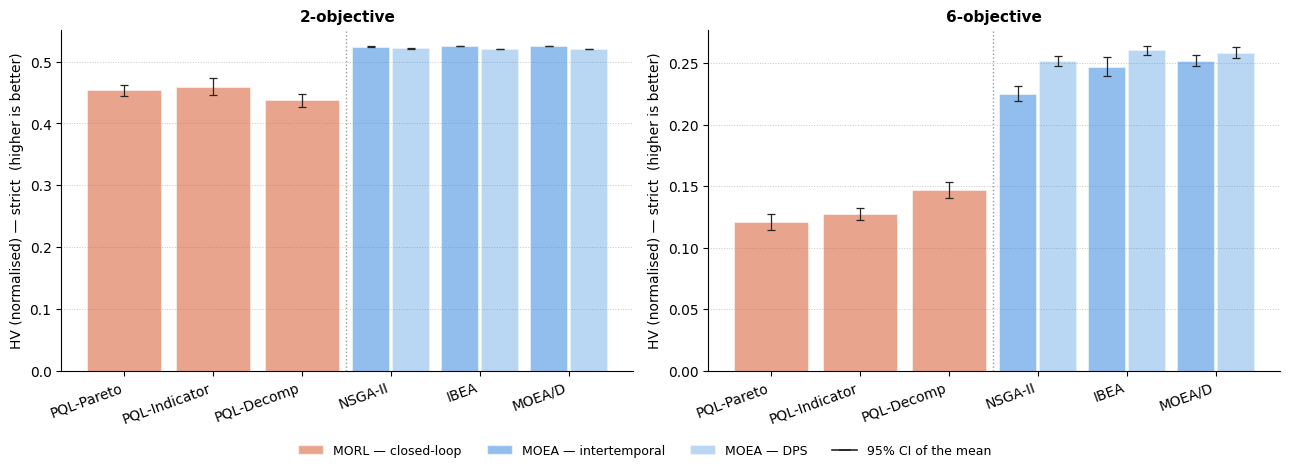

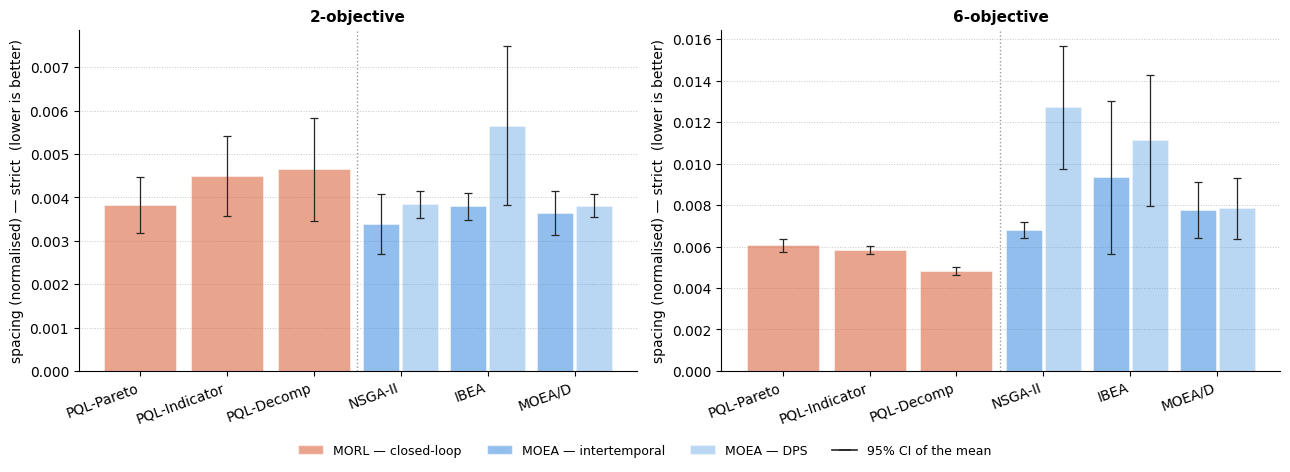

In [4]:
A.figure_metrics_separate(
    df, metrics=METRICS, n_objs=N_OBJS, modes=MODES,
    condition_style=CONDITION_STYLE,
    condition_label=CONDITION_LABEL,
    condition_order=CONDITION_ORDER,
    # suptitle='MORL vs MOEA — deterministic constrained lake (closed-loop)',
    out_path=os.path.join(OUT_DIR, 'fig1_det_constrained_lake_metrics.png'))

### Figure 2 — Solution counts


Saved ./constrained_lake_figures/fig2_det_constrained_lake_counts.png


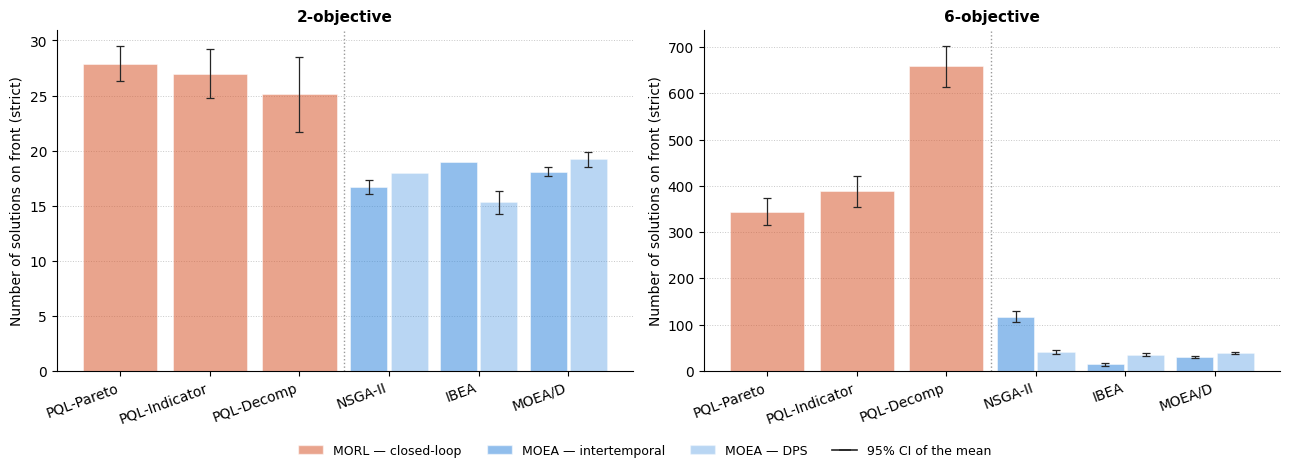

In [5]:
A.figure_counts(
    df, n_objs=N_OBJS, modes=MODES,
    condition_style=CONDITION_STYLE,
    condition_label=CONDITION_LABEL,
    condition_order=CONDITION_ORDER,
    # suptitle='Number of solutions on the re-evaluated front — '
    #          'deterministic constrained lake',
    out_path=os.path.join(OUT_DIR, 'fig2_det_constrained_lake_counts.png'))

### Figure 3 — Convergence (MOEA + MORL)


MOEA: 120 curves; MORL: 60 curves
Saved ./constrained_lake_figures/fig3_det_constrained_lake_conv_moea.png
Saved ./constrained_lake_figures/fig3_det_constrained_lake_conv_morl.png


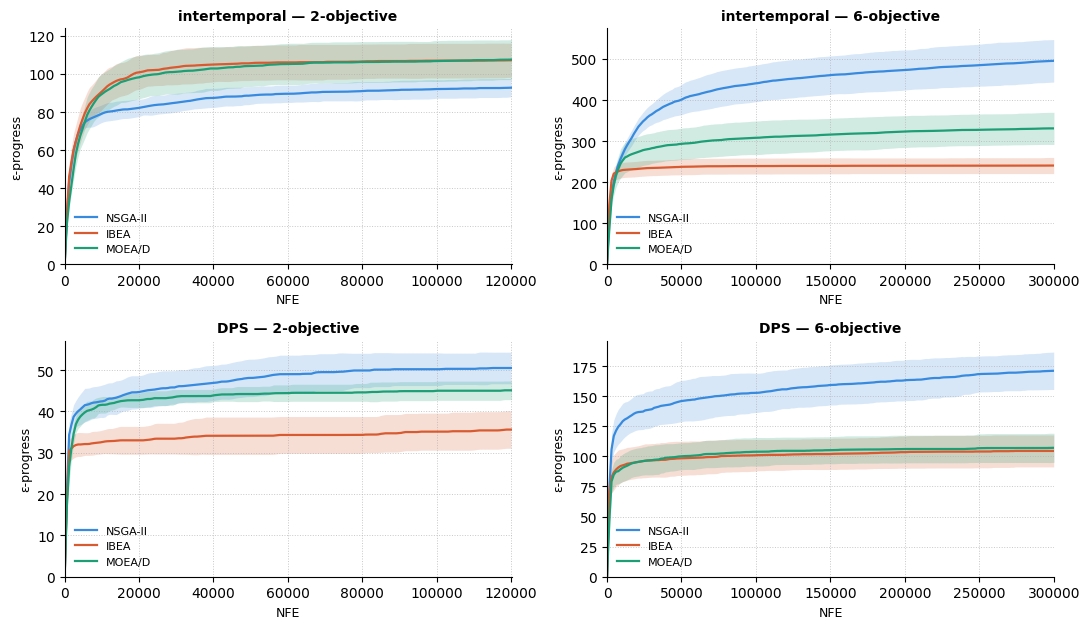

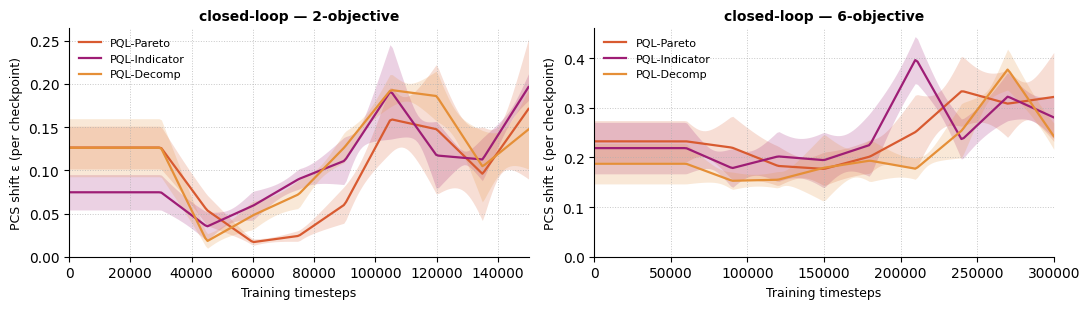

In [8]:
moea_records = A.load_convergences(
    os.path.dirname(MOEA_CSV), folder_re=MOEA_FOLDER_RE,
    condition_format=moea_fmt, csv_prefix='convergences_',
    x_col='nfe', y_col='epsilon_progress')
morl_records = A.load_convergences(
    os.path.dirname(MORL_CSV), folder_re=MORL_FOLDER_RE,
    condition_format=morl_fmt, csv_prefix='convergence_',
    x_col='timestep', y_col='pcs_shift_eps', dropna_y=True)
print(f'MOEA: {len(moea_records)} curves; '
      f'MORL: {len(morl_records)} curves')

A.figure_convergence(
    moea_records, methods=MOEA_METHODS,
    conditions=['intertemporal_single', 'dps_single'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='NFE', ylabel='ε-progress',
    # suptitle='MOEA convergence — deterministic constrained lake',
    out_path=os.path.join(OUT_DIR, 'fig3_det_constrained_lake_conv_moea.png'))

A.figure_convergence(
    morl_records, methods=MORL_METHODS,
    conditions=['closed_loop_single'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='Training timesteps',
    ylabel='PCS shift ε (per checkpoint)',
    # suptitle='MORL convergence — deterministic constrained lake',
    out_path=os.path.join(OUT_DIR, 'fig3_det_constrained_lake_conv_morl.png'))

### Runtime summary


In [9]:
rt_rows = (
    A.collect_runtimes(os.path.dirname(MOEA_CSV),
        folder_re=MOEA_FOLDER_RE, paradigm='MOEA',
        condition_format=moea_fmt, csv_prefix='convergences_',
        mode='per_file')
    + A.collect_runtimes(os.path.dirname(MORL_CSV),
        folder_re=MORL_FOLDER_RE, paradigm='MORL',
        condition_format=morl_fmt, csv_prefix='convergence_',
        mode='per_file')
)
rt_df = pd.DataFrame(rt_rows)
print(f'Total runs: {len(rt_df)}')
A.summarize_runtimes(rt_df, title='Deterministic constrained lake runtime', metrics_df=df, modes=MODES)

Total runs: 180

=== Deterministic constrained lake runtime ===



,paradigm,method,condition,n_obj,count,mean_hms,std_hms,total_hms,n_infeasible_strict_mean,n_infeasible_strict_std,n_dom_strict_mean,n_dom_strict_std,n_solutions_strict_mean,n_solutions_strict_std
0,MOEA,IBEA,dps_single,2,10,5m09s,0m18s,51m30s,0.0,0.0,0.0,0.0,15.3,1.4
1,MOEA,IBEA,dps_single,6,10,44m40s,2m40s,7h26m40s,0.0,0.0,0.0,0.0,35.3,4.2
2,MOEA,IBEA,intertemporal_single,2,10,5m33s,0m26s,55m30s,0.0,0.0,0.0,0.0,19.0,0.0
3,MOEA,IBEA,intertemporal_single,6,10,46m13s,1m54s,7h42m10s,0.0,0.0,0.0,0.0,14.0,5.0
4,MOEA,MOEAD,dps_single,2,10,6m43s,0m13s,1h07m10s,0.0,0.0,0.0,0.0,19.2,0.9
5,MOEA,MOEAD,dps_single,6,10,19m03s,0m52s,3h10m30s,0.0,0.0,0.0,0.0,39.5,3.1
6,MOEA,MOEAD,intertemporal_single,2,10,10m08s,0m49s,1h41m20s,0.0,0.0,0.0,0.0,18.1,0.6
7,MOEA,MOEAD,intertemporal_single,6,10,26m52s,2m00s,4h28m40s,0.0,0.0,0.0,0.0,30.8,3.5
8,MOEA,NSGAII,dps_single,2,10,1m16s,0m03s,12m40s,0.0,0.0,0.0,0.0,18.0,0.0
9,MOEA,NSGAII,dps_single,6,10,4m07s,0m08s,41m10s,0.0,0.0,0.0,0.0,41.2,5.6


## Robust
In robust data, strict and tolerant differ — set `MODES = ['strict']` to see both as separate rows in the figures, or pick one.


### Configuration


In [10]:
MORL_CSV = '../data/constrained_lake/robust/morl/metrics_long_reeval.csv'
MOEA_CSV = '../data/constrained_lake/robust/moea/metrics_long_reeval.csv'

MODES = ['strict']

CONDITION_STYLE = {
    'closed_loop_multi':   dict(alpha=0.55, hatch=''),
    'closed_loop_moro':    dict(alpha=0.30, hatch='..'),
    'intertemporal_multi': dict(alpha=0.55, hatch=''),
    'intertemporal_moro':  dict(alpha=0.55, hatch='..'),
    'dps_multi':           dict(alpha=0.35, hatch=''),
    'dps_moro':            dict(alpha=0.35, hatch='..'),
}
CONDITION_LABEL = {
    'closed_loop_multi':   'closed-loop · multi',
    'closed_loop_moro':    'closed-loop · ro',
    'intertemporal_multi': 'intertemporal · multi',
    'intertemporal_moro':  'intertemporal · ro',
    'dps_multi':           'DPS · multi',
    'dps_moro':            'DPS · ro',
}
CONDITION_ORDER = [
    'closed_loop_multi', 'closed_loop_moro',
    'intertemporal_multi', 'intertemporal_moro',
    'dps_multi', 'dps_moro',
]

MOEA_FOLDER_RE = re.compile(
    r'^(intertemporal|dps)_(NSGAII|IBEA|MOEAD)_(multi|moro)_(\d+)$')
MORL_FOLDER_RE = re.compile(
    r'^(pareto|indicator|decomposition)_(multi|moro)_(\d+)$')

def moea_fmt(groups):
    policy, algo, scenm, n_obj = groups
    return f'{policy}_{scenm}', algo, int(n_obj)

def morl_fmt(groups):
    scoring, scenm, n_obj = groups
    return f'closed_loop_{scenm}', scoring, int(n_obj)

### Load + summary


In [11]:
df = A.load_metrics(MORL_CSV, MOEA_CSV, metrics=METRICS,
                    modes=MODES)
A.print_metric_summary(df, metrics=METRICS, n_objs=N_OBJS,
                       condition_order=CONDITION_ORDER,
                       modes=MODES)

paradigm method        condition                    n_obj    n    n_dom·str     ±std    hv_ratio·str      ±std  spacing_norm·s      ±std
MORL     PQL-Pareto    closed_loop_multi                2   10         11.9      3.3         0.08795   0.00865         0.00136   0.00037
MORL     PQL-Pareto    closed_loop_moro                 2   10          1.5      1.3         0.06863   0.01539         0.00220   0.00108
MORL     PQL-Indicator closed_loop_multi                2   10          7.7      5.3         0.09381   0.00873         0.00189   0.00067
MORL     PQL-Indicator closed_loop_moro                 2   10          1.2      0.8         0.06780   0.01879         0.00215   0.00102
MORL     PQL-Decomp    closed_loop_multi                2   10         15.8      4.7         0.07988   0.00802         0.00132   0.00056
MORL     PQL-Decomp    closed_loop_moro                 2   10          1.2      0.9         0.06550   0.00893         0.00174   0.00082
MOEA     NSGA-II       intertemporal_mult

### Figure 1 — HV ratio + spacing (box plots)


Saved ./constrained_lake_figures/fig1_robust_constrained_lake_metrics_strict_hv_ratio.png
Saved ./constrained_lake_figures/fig1_robust_constrained_lake_metrics_strict_spacing_norm.png


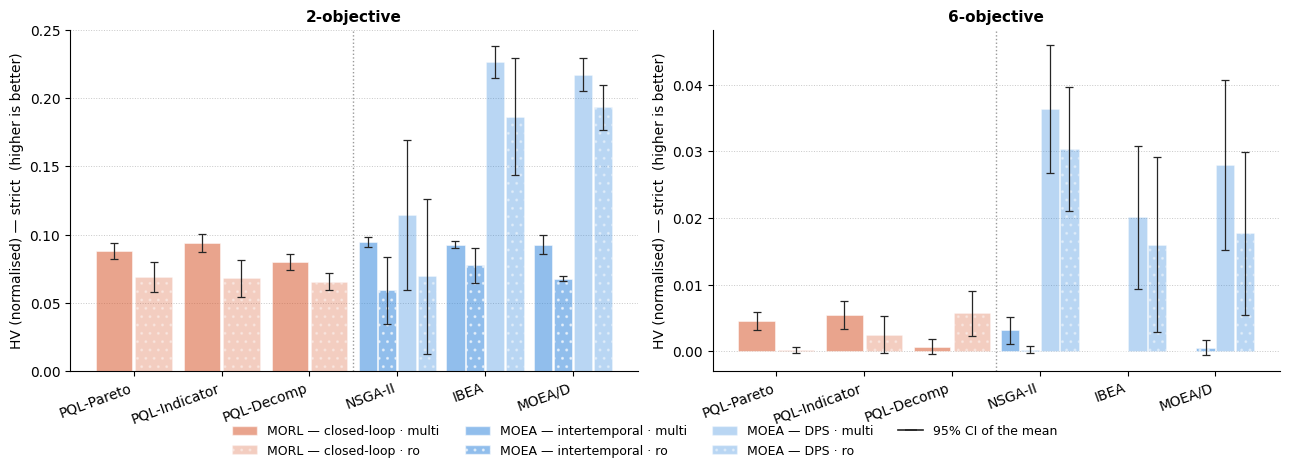

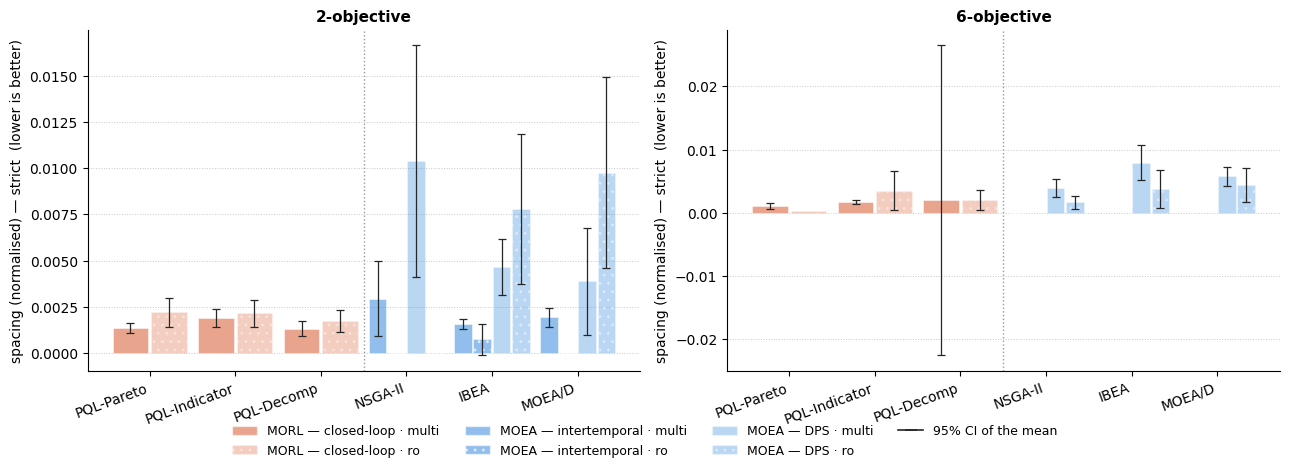

In [12]:
A.figure_metrics_separate(
    df, metrics=METRICS, n_objs=N_OBJS, modes=MODES,
    condition_style=CONDITION_STYLE,
    condition_label=CONDITION_LABEL,
    condition_order=CONDITION_ORDER,
    # suptitle='MORL vs MOEA — robust constrained lake (closed-loop)',
    out_path=os.path.join(OUT_DIR, f'fig1_robust_constrained_lake_metrics_{MODES[0]}.png'))

### Figure 2 — Solution counts


Saved ./constrained_lake_figures/fig2_robust_constrained_lake_counts_strict.png


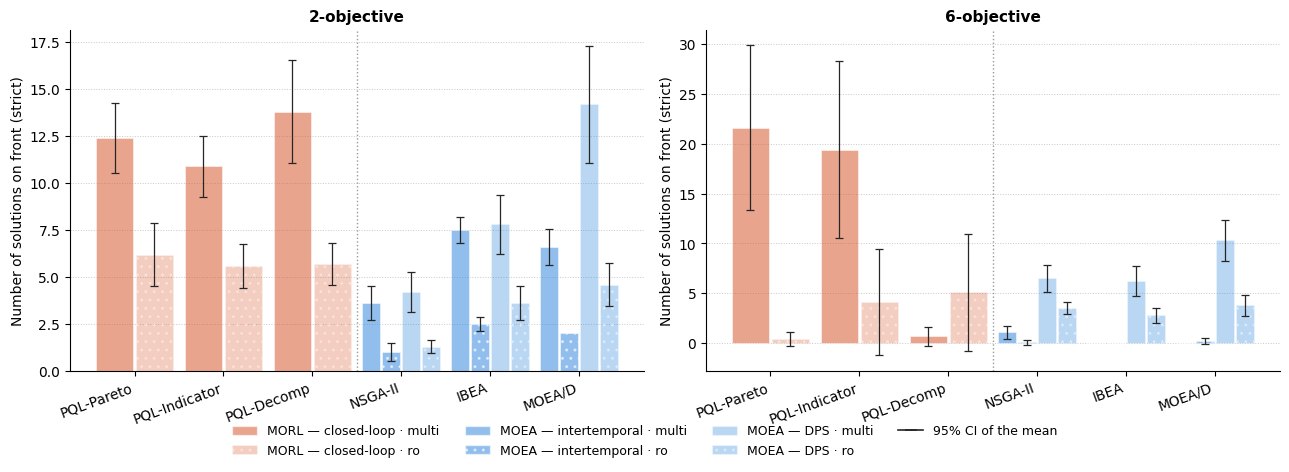

In [13]:
A.figure_counts(
    df, n_objs=N_OBJS, modes=MODES,
    condition_style=CONDITION_STYLE,
    condition_label=CONDITION_LABEL,
    condition_order=CONDITION_ORDER,
    # suptitle='Number of solutions on the re-evaluated front — '
    #          'robust constrained lake',
    out_path=os.path.join(OUT_DIR, f'fig2_robust_constrained_lake_counts_{MODES[0]}.png'))

### Figure 3 — Convergence (MOEA + MORL)


MOEA: 720 curves; MORL: 360 curves
Saved ./constrained_lake_figures/fig3_robust_constrained_lake_conv_moea.png
Saved ./constrained_lake_figures/fig3_robust_constrained_lake_conv_morl.png


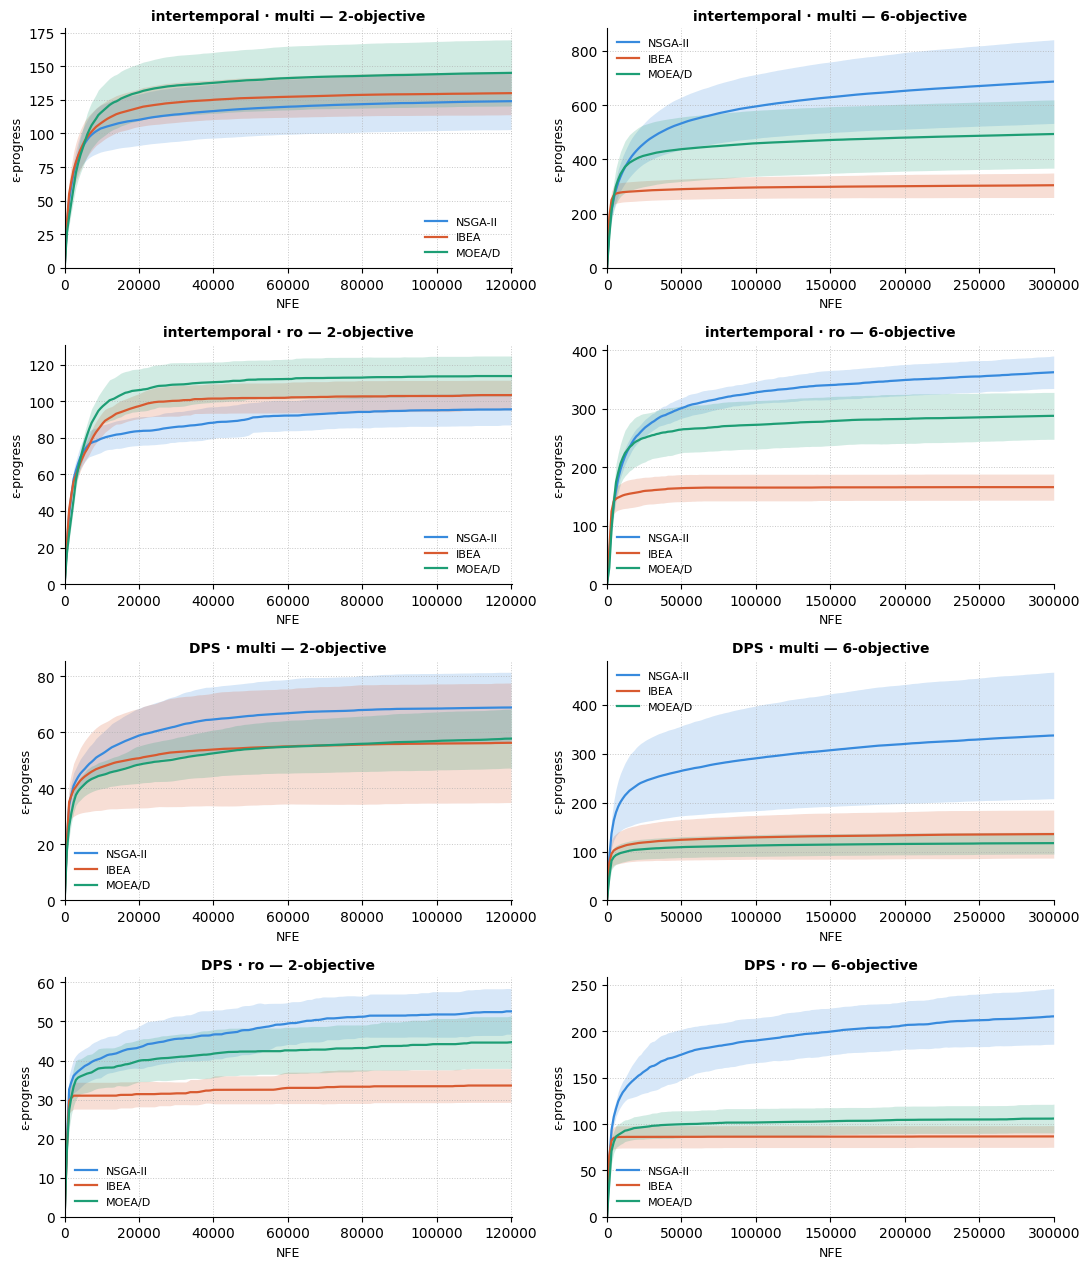

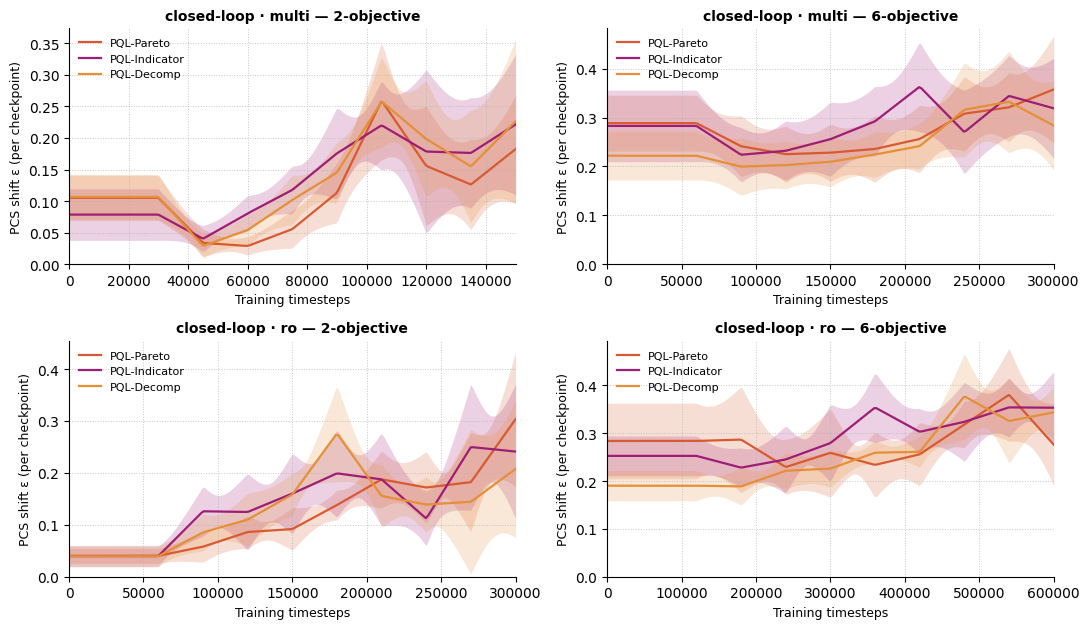

In [14]:
moea_records = A.load_convergences(
    os.path.dirname(MOEA_CSV), folder_re=MOEA_FOLDER_RE,
    condition_format=moea_fmt, csv_prefix='convergences_',
    x_col='nfe', y_col='epsilon_progress')
morl_records = A.load_convergences(
    os.path.dirname(MORL_CSV), folder_re=MORL_FOLDER_RE,
    condition_format=morl_fmt, csv_prefix='convergence_',
    x_col='timestep', y_col='pcs_shift_eps', dropna_y=True)
print(f'MOEA: {len(moea_records)} curves; '
      f'MORL: {len(morl_records)} curves')

A.figure_convergence(
    moea_records, methods=MOEA_METHODS,
    conditions=['intertemporal_multi', 'intertemporal_moro',
                'dps_multi', 'dps_moro'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='NFE', ylabel='ε-progress',
    # suptitle='MOEA convergence — robust constrained lake',
    out_path=os.path.join(OUT_DIR, 'fig3_robust_constrained_lake_conv_moea.png'))

A.figure_convergence(
    morl_records, methods=MORL_METHODS,
    conditions=['closed_loop_multi', 'closed_loop_moro'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='Training timesteps',
    ylabel='PCS shift ε (per checkpoint)',
    # suptitle='MORL convergence — robust constrained lake',
    out_path=os.path.join(OUT_DIR, 'fig3_robust_constrained_lake_conv_morl.png'))

### Runtime summary


In [15]:
rt_rows = (
    A.collect_runtimes(os.path.dirname(MOEA_CSV),
        folder_re=MOEA_FOLDER_RE, paradigm='MOEA',
        condition_format=moea_fmt, csv_prefix='convergences_',
        mode='per_seed')
    + A.collect_runtimes(os.path.dirname(MORL_CSV),
        folder_re=MORL_FOLDER_RE, paradigm='MORL',
        condition_format=morl_fmt, csv_prefix='convergence_',
        mode='per_seed')
)
rt_df = pd.DataFrame(rt_rows)
print(f'Total runs: {len(rt_df)}')
A.summarize_runtimes(rt_df, title='Robust constrained lake runtime', metrics_df=df, modes=MODES)

Total runs: 360

=== Robust constrained lake runtime ===



,paradigm,method,condition,n_obj,count,mean_hms,std_hms,total_hms,n_infeasible_strict_mean,n_infeasible_strict_std,n_dom_strict_mean,n_dom_strict_std,n_solutions_strict_mean,n_solutions_strict_std
0,MOEA,IBEA,dps_moro,2,10,18m02s,1m33s,3h00m20s,12.4,1.9,0.0,0.0,3.6,1.3
1,MOEA,IBEA,dps_moro,6,10,1h20m58s,3m04s,13h29m40s,25.4,4.6,0.0,0.0,2.8,1.0
2,MOEA,IBEA,dps_multi,2,10,25m15s,1m12s,4h12m30s,92.8,3.6,3.5,1.0,7.8,2.2
3,MOEA,IBEA,dps_multi,6,10,3h31m26s,8m57s,35h14m20s,220.4,5.7,0.2,0.4,6.2,2.1
4,MOEA,IBEA,intertemporal_moro,2,10,18m30s,2m30s,3h05m00s,16.3,0.5,0.0,0.0,2.5,0.5
5,MOEA,IBEA,intertemporal_moro,6,10,1h30m02s,6m37s,15h00m20s,15.6,2.5,0.0,0.0,0.0,0.0
6,MOEA,IBEA,intertemporal_multi,2,10,27m42s,1m22s,4h37m00s,101.9,2.2,3.4,1.2,7.5,1.0
7,MOEA,IBEA,intertemporal_multi,6,10,3h41m05s,8m28s,36h50m50s,93.5,10.4,0.0,0.0,0.0,0.0
8,MOEA,MOEAD,dps_moro,2,10,17m03s,1m39s,2h50m30s,13.7,2.1,0.0,0.0,4.6,1.6
9,MOEA,MOEAD,dps_moro,6,10,47m30s,3m00s,7h55m00s,32.4,4.2,0.0,0.0,3.8,1.5
